<a href="https://colab.research.google.com/github/ryueuitae/AIEYES-STUDY/blob/huisoo_branch/week06%2607_%EC%95%BC%EA%B5%AC%EC%84%A0%EC%88%98_%EC%97%B0%EB%B4%89%EC%98%88%EC%B8%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#분석 환경 세팅

%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
#폰트 불러오기
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os, shutil

# 캐시 삭제 (새 API)
cache_dir = os.path.expanduser('~/.cache/matplotlib')
shutil.rmtree(cache_dir, ignore_errors=True)
os.makedirs(cache_dir, exist_ok=True)

fm._load_fontmanager(try_read_cache=False)

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

#폰트 적용 여부 확인
print("적용된 폰트:", plt.rcParams['font.family'])
print("폰트 파일 존재:", os.path.exists(font_path))

적용된 폰트: ['NanumGothic']
폰트 파일 존재: True


In [3]:
#파일 불러오기
picher_file_path ='/content/picher_stats_2017.csv' #투수 데이터
batter_file_path ='/content/batter_stats_2017.csv' #타자 데이터
picher = pd.read_csv(picher_file_path)
batter = pd.read_csv(batter_file_path)

In [4]:
picher.columns

Index(['선수명', '팀명', '승', '패', '세', '홀드', '블론', '경기', '선발', '이닝', '삼진/9',
       '볼넷/9', '홈런/9', 'BABIP', 'LOB%', 'ERA', 'RA9-WAR', 'FIP', 'kFIP', 'WAR',
       '연봉(2018)', '연봉(2017)'],
      dtype='object')

In [5]:
picher.head()

#회귀분석을 한다면... 2018년 연봉이 y, 나머지 속성이 x일 것.

,선수명,팀명,승,패,세,홀드,블론,경기,선발,이닝,...,홈런/9,BABIP,LOB%,ERA,RA9-WAR,FIP,kFIP,WAR,연봉(2018),연봉(2017)
0,켈리,SK,16,7,0,0,0,30,30,190.0,...,0.76,0.342,73.7,3.60,6.91,3.69,3.44,6.62,140000,85000
1,소사,LG,11,11,1,0,0,30,29,185.1,...,0.53,0.319,67.1,3.88,6.80,3.52,3.41,6.08,120000,50000
2,양현종,KIA,20,6,0,0,0,31,31,193.1,...,0.79,0.332,72.1,3.44,6.54,3.94,3.82,5.64,230000,150000
3,차우찬,LG,10,7,0,0,0,28,28,175.2,...,1.02,0.298,75.0,3.43,6.11,4.20,4.03,4.63,100000,100000
4,레일리,롯데,13,7,0,0,0,30,30,187.1,...,0.91,0.323,74.1,3.80,6.13,4.36,4.31,4.38,111000,85000


In [6]:
print(picher.shape)

(152, 22)


In [7]:
#저장된 폰트 확인
import matplotlib as mpl
set(sorted([f.name for f in mpl.font_manager.fontManager.ttflist])) # 현재 OS 내에 설치된 폰트 확인

{'DejaVu Sans',
 'DejaVu Sans Display',
 'DejaVu Sans Mono',
 'DejaVu Serif',
 'DejaVu Serif Display',
 'Humor Sans',
 'Liberation Mono',
 'Liberation Sans',
 'Liberation Sans Narrow',
 'Liberation Serif',
 'NanumBarunGothic',
 'NanumGothic',
 'NanumGothicCoding',
 'NanumMyeongjo',
 'NanumSquare',
 'NanumSquareRound',
 'STIXGeneral',
 'STIXNonUnicode',
 'STIXSizeFiveSym',
 'STIXSizeFourSym',
 'STIXSizeOneSym',
 'STIXSizeThreeSym',
 'STIXSizeTwoSym',
 'cmb10',
 'cmex10',
 'cmmi10',
 'cmr10',
 'cmss10',
 'cmsy10',
 'cmtt10'}

In [8]:
#나눔고딕 폰트를 사용하자!
mpl.rc('font', family='NanumGothic')

<Axes: >

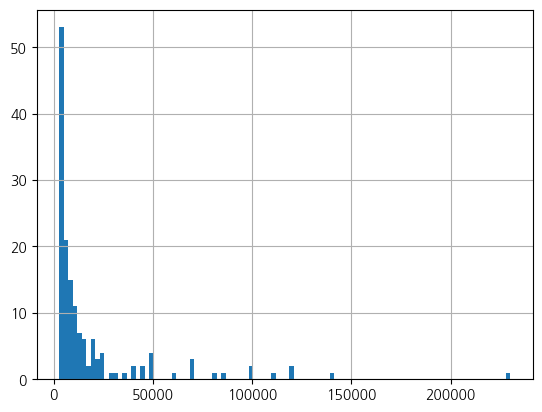

In [9]:
#2018년 연봉의 분포를 출력
picher['연봉(2018)'].hist(bins=100)

#5억 이하의 연봉을 받는 선수들이 대다수이다.

<Axes: >

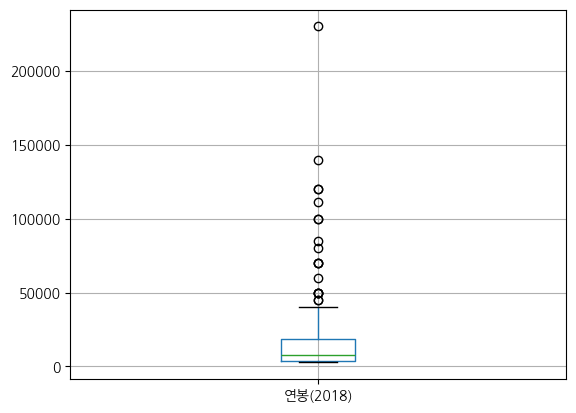

In [11]:
#2018 연봉의 Box Plot 그리기
picher.boxplot(column=['연봉(2018)'])

#고액 연봉자들이 매우 많으며,최댓값의 경우 그 정도가 매우 심하다.

# 회귀분석에 사용할 피처 살펴보기

In [12]:
#우선 투수의 피쳐명을 다룬 df를 생성해준다(총 15개의 피쳐)
picher_features_df = picher[['승', '패', '세', '홀드', '블론', '경기', '선발', '이닝', '삼진/9',
       '볼넷/9', '홈런/9', 'BABIP', 'LOB%', 'ERA', 'RA9-WAR', 'FIP', 'kFIP', 'WAR',
       '연봉(2018)', '연봉(2017)']]

In [13]:
# 피처 각각에 대한 히스토그램을 출력하는 함수를 정의
def plot_hist_each_column(df):
    plt.rcParams['figure.figsize'] = [20, 16]
    fig = plt.figure(1)

    #for문을 활용해 데이터프레임의 column 갯수, 즉 피쳐 수 만큼의 subplot을 출력
    for i in range(len(df.columns)):
        ax = fig.add_subplot(5, 5, i+1)
        plt.hist(df[df.columns[i]], bins=50)
        ax.set_title(df.columns[i])
    plt.show()

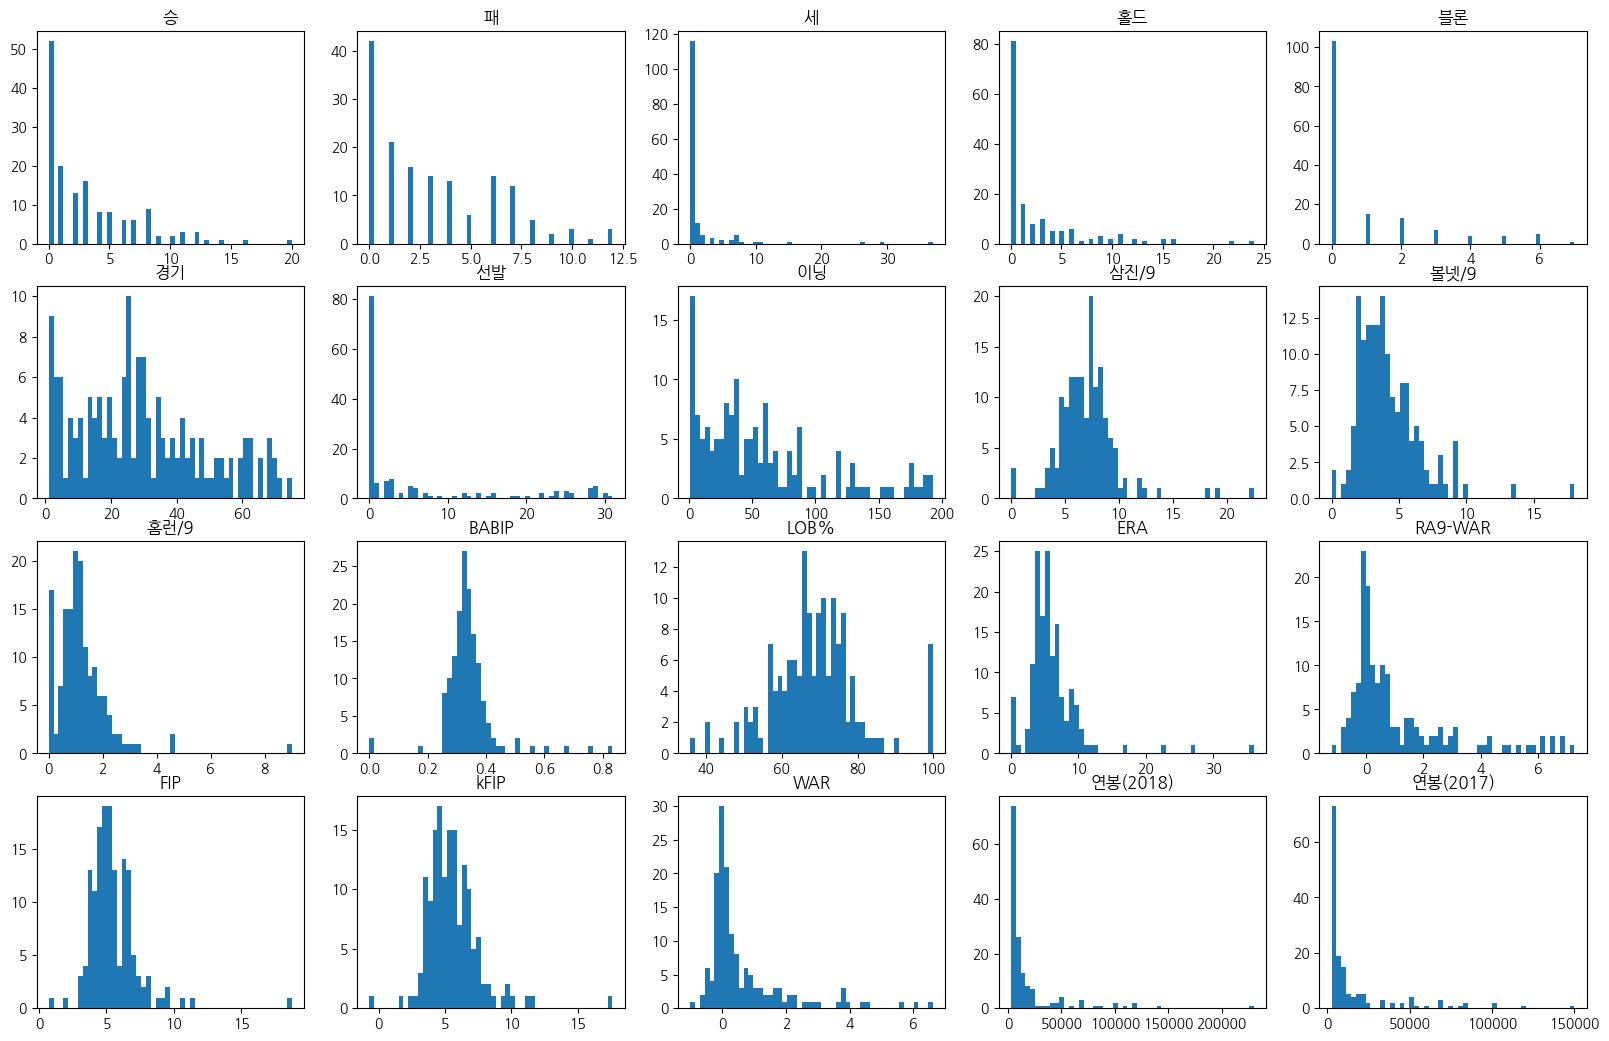

In [14]:
plot_hist_each_column(picher_features_df)

#단위가 천차만별인 것을 확인할 수 있다.
#대부분의 그래프가 종상 또는 급격히 감소하는 모습을 보인다.

#투수의 연봉 예측하기

### 피쳐들의 단위 맞추기 -> 피쳐 스케일링

In [15]:
# pandas 형태로 정의된 데이터를 출력할 때, scientific-notation이 아닌 float 모양으로 출력되도록 설정
pd.options.mode.chained_assignment = None

In [16]:
# 피처 각각에 대해 스케일링을 수행하는 함수를 정의

def standard_scaling(df, scale_columns):
    for col in scale_columns:
        series_mean = df[col].mean() #평균과 표준편차를 구하여
        series_std = df[col].std()
        df[col] = df[col].apply(lambda x: (x-series_mean)/series_std) #z-score를 구한다
    return df

In [17]:
# 피처 각각에 대해 스케일링을 수행
# 이때 y값에 해당하는 2018년 연봉을 제외한다
scale_columns = ['승', '패', '세', '홀드', '블론', '경기', '선발', '이닝', '삼진/9',
       '볼넷/9', '홈런/9', 'BABIP', 'LOB%', 'ERA', 'RA9-WAR', 'FIP', 'kFIP', 'WAR', '연봉(2017)']

picher_df = standard_scaling(picher, scale_columns)

In [18]:
#연봉(2018)을 y로 리네이밍
picher_df = picher_df.rename(columns={'연봉(2018)': 'y'})
picher_df.head(5)

#x에 해당하는 피쳐들을 -5에서 5 사이의 z-score 값으로 바꿔주었다. 역시 y는 그대로

,선수명,팀명,승,패,세,홀드,블론,경기,선발,이닝,...,홈런/9,BABIP,LOB%,ERA,RA9-WAR,FIP,kFIP,WAR,y,연봉(2017)
0,켈리,SK,3.313623,1.227145,-0.306452,-0.585705,-0.543592,0.059433,2.452068,2.645175,...,-0.442382,0.016783,0.446615,-0.587056,3.174630,-0.971030,-1.058125,4.503142,140000,2.734705
1,소사,LG,2.019505,2.504721,-0.098502,-0.585705,-0.543592,0.059433,2.349505,2.547755,...,-0.668521,-0.241686,-0.122764,-0.519855,3.114968,-1.061888,-1.073265,4.094734,120000,1.337303
2,양현종,KIA,4.348918,0.907751,-0.306452,-0.585705,-0.543592,0.111056,2.554632,2.706808,...,-0.412886,-0.095595,0.308584,-0.625456,2.973948,-0.837415,-0.866361,3.761956,230000,5.329881
3,차우찬,LG,1.760682,1.227145,-0.306452,-0.585705,-0.543592,-0.043811,2.246942,2.350927,...,-0.186746,-0.477680,0.558765,-0.627856,2.740722,-0.698455,-0.760385,2.998081,100000,3.333592
4,레일리,롯데,2.537153,1.227145,-0.306452,-0.585705,-0.543592,0.059433,2.452068,2.587518,...,-0.294900,-0.196735,0.481122,-0.539055,2.751570,-0.612941,-0.619085,2.809003,111000,2.734705


### 피쳐들의 단위 맞춰주기 -> one-hot-encoding



In [19]:
#팀명은 범주형 자료... 이걸 그대로 회귀분석에 사용할 수 없다!
#판다스의 get_dummies를 통해 원핫 인코딩을 수행
team_encoding = pd.get_dummies(picher_df['팀명'])
picher_df = picher_df.drop('팀명', axis=1)
picher_df = picher_df.join(team_encoding)

In [20]:
team_encoding.head(5)

#True/False로 나타나긴 하지만 원 핫 인코딩이 잘 수행된 것을 확인할 수 있다

,KIA,KT,LG,NC,SK,두산,롯데,삼성,한화
0,False,False,False,False,True,False,False,False,False
1,False,False,True,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False


# 회귀 분석 수행

In [21]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt

#데이터 분리에 앞서 X와 Y부터 분리
X = picher_df[picher_df.columns.difference(['선수명', 'y'])] #X는 선수명과 y를 제외한 나머지
y = picher_df['y']

# 4:1의 비율로 train 데이터와 test 데이터를 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19)

In [22]:
X_train.shape

(121, 28)

In [23]:
y_train.shape

(121,)

In [24]:
X_test.shape

(31, 28)

In [25]:
y_test.shape

(31,)

### 회귀분석 계수 학습 및 출력

In [26]:
#회귀 분석을 위해 계수를 학습
lr = linear_model.LinearRegression() #선형 회귀 모델 오브젝트 생성
model = lr.fit(X_train, y_train) #학습!

In [27]:
# 학습된 계수 출력
print(lr.coef_)

#매우 큰 계수가 등장하는 것이 신기

[ -1481.01733901   -416.68736601 -94136.23649209  -1560.86205158
   1572.00472193   -747.04952389  -1375.53830289   -523.54687556
   3959.10653661    898.37638984  10272.48746451  77672.53804469
  -2434.38947427   -892.11801281    449.91117164   7612.15661812
   1271.04500059  -2810.55645139   5396.97279896  -4797.30275904
   -250.69773139    236.02530053  19130.59021357    854.02604585
   1301.61974637   3613.84063182   -935.07281796  18144.60099745]


# 예측 모델 평가하기


평가 방법은 크게 두개...
1. 계수 크기를 보고 영향력 평가
2. 통계적 회귀분석으로 각각의 변수에 대한 p-value 확인

In [32]:
!pip install statsmodels

In [34]:
import statsmodels.api as sm

# statsmodel 라이브러리로 회귀 분석 수행
# 에러 발생 - 원 핫 인코딩 수행했을때 bool형으로 남았던게 문제가 됨.. 다시 float으로 변환
X_train = X_train.astype(float)
X_train = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train).fit()
model.summary()

#R-squared: 선형회귀의 직선이 데이터들과 얼마나 잘 붙어 있는가?
#F-statistic: 모델의 수행이 얼마나 잘 이루어졌는지 검증하는 수치
#Prob (F-statistic): F에 대한 p-value. 결과값에서는 매우 작으므로 회귀분석의 신뢰도가 높아진다.
#p-value를 확인해보면 WAR나 연봉(2017)같은 피쳐들이 매우 유의미함을 알 수 있다.

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.907
Method:                 Least Squares   F-statistic:                     44.19
Date:                Mon, 25 May 2026   Prob (F-statistic):           7.70e-42
Time:                        13:17:55   Log-Likelihood:                -1247.8
No. Observations:                 121   AIC:                             2552.
Df Residuals:                      93   BIC:                             2630.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.678e+04    697.967     24.036      0.000    1.54e+04    1.82e+04
BABIP      -1481.0173   1293.397     -1.145      0.255   -4049.448    1087.414
ERA         -416.6874   2322.402     -0.179      0.858   -5028.517    4195.143
FIP        -9.414e+04   9.43e+04     -0.998      0.321   -2.81e+05    9.31e+04
KIA          303.1852   2222.099      0.136      0.892   -4109.462    4715.833
KT          3436.0520   2133.084      1.611      0.111    -799.831    7671.935
LG          1116.9978   2403.317      0.465      0.643   -3655.513    5889.509
LOB%       -1375.5383   1564.806     -0.879      0.382   -4482.933    1731.857
NC          1340.5004   2660.966      0.504      0.616   -3943.651    6624.652
RA9-WAR     3959.1065   2931.488      1.351      0.180   -1862.247    9780.460
SK          2762.4237   2243.540      1.231      0.221   -1692.803    7217.650
WAR         1.027e+04   2532.309      4.057      0.000    5243.823    1.53e+04
kFIP        7.767e+04   7.95e+04      0.977      0.331   -8.03e+04    2.36e+05
경기         -2434.3895   2953.530     -0.824      0.412   -8299.515    3430.736
두산           971.9293   2589.849      0.375      0.708   -4170.998    6114.857
롯데          2313.9585   2566.009      0.902      0.370   -2781.627    7409.544
볼넷/9        7612.1566   6275.338      1.213      0.228   -4849.421    2.01e+04
블론          1271.0450   1242.128      1.023      0.309   -1195.576    3737.666
삼성          -946.5092   2482.257     -0.381      0.704   -5875.780    3982.762
삼진/9        5396.9728   7286.221      0.741      0.461   -9072.019    1.99e+04
선발         -4797.3028   5489.352     -0.874      0.384   -1.57e+04    6103.463
세           -250.6977   1295.377     -0.194      0.847   -2823.059    2321.663
승            236.0253   2215.264      0.107      0.915   -4163.049    4635.100
연봉(2017)    1.913e+04   1270.754     15.055      0.000    1.66e+04    2.17e+04
이닝           854.0260   6623.940      0.129      0.898   -1.23e+04     1.4e+04
패           1301.6197   1935.935      0.672      0.503   -2542.763    5146.003
한화          5477.8879   2184.273      2.508      0.014    1140.355    9815.421
홀드          -935.0728   1637.923     -0.571      0.569   -4187.663    2317.518
홈런/9        1.814e+04   1.68e+04      1.082      0.282   -1.52e+04    5.14e+04
==============================================================================
Omnibus:                       28.069   Durbin-Watson:                   2.025
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              194.274
Skew:                          -0.405   Prob(JB):                     6.52e-43
Kurtosis:                       9.155   Cond. No.                     3.28e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is co

[Text(0, 0, 'const'),
 Text(1, 0, 'BABIP'),
 Text(2, 0, 'ERA'),
 Text(3, 0, 'FIP'),
 Text(4, 0, 'KIA'),
 Text(5, 0, 'KT'),
 Text(6, 0, 'LG'),
 Text(7, 0, 'LOB%'),
 Text(8, 0, 'NC'),
 Text(9, 0, 'RA9-WAR'),
 Text(10, 0, 'SK'),
 Text(11, 0, 'WAR'),
 Text(12, 0, 'kFIP'),
 Text(13, 0, '경기'),
 Text(14, 0, '두산'),
 Text(15, 0, '롯데'),
 Text(16, 0, '볼넷/9'),
 Text(17, 0, '블론'),
 Text(18, 0, '삼성'),
 Text(19, 0, '삼진/9'),
 Text(20, 0, '선발'),
 Text(21, 0, '세'),
 Text(22, 0, '승'),
 Text(23, 0, '연봉(2017)'),
 Text(24, 0, '이닝'),
 Text(25, 0, '패'),
 Text(26, 0, '한화'),
 Text(27, 0, '홀드'),
 Text(28, 0, '홈런/9')]

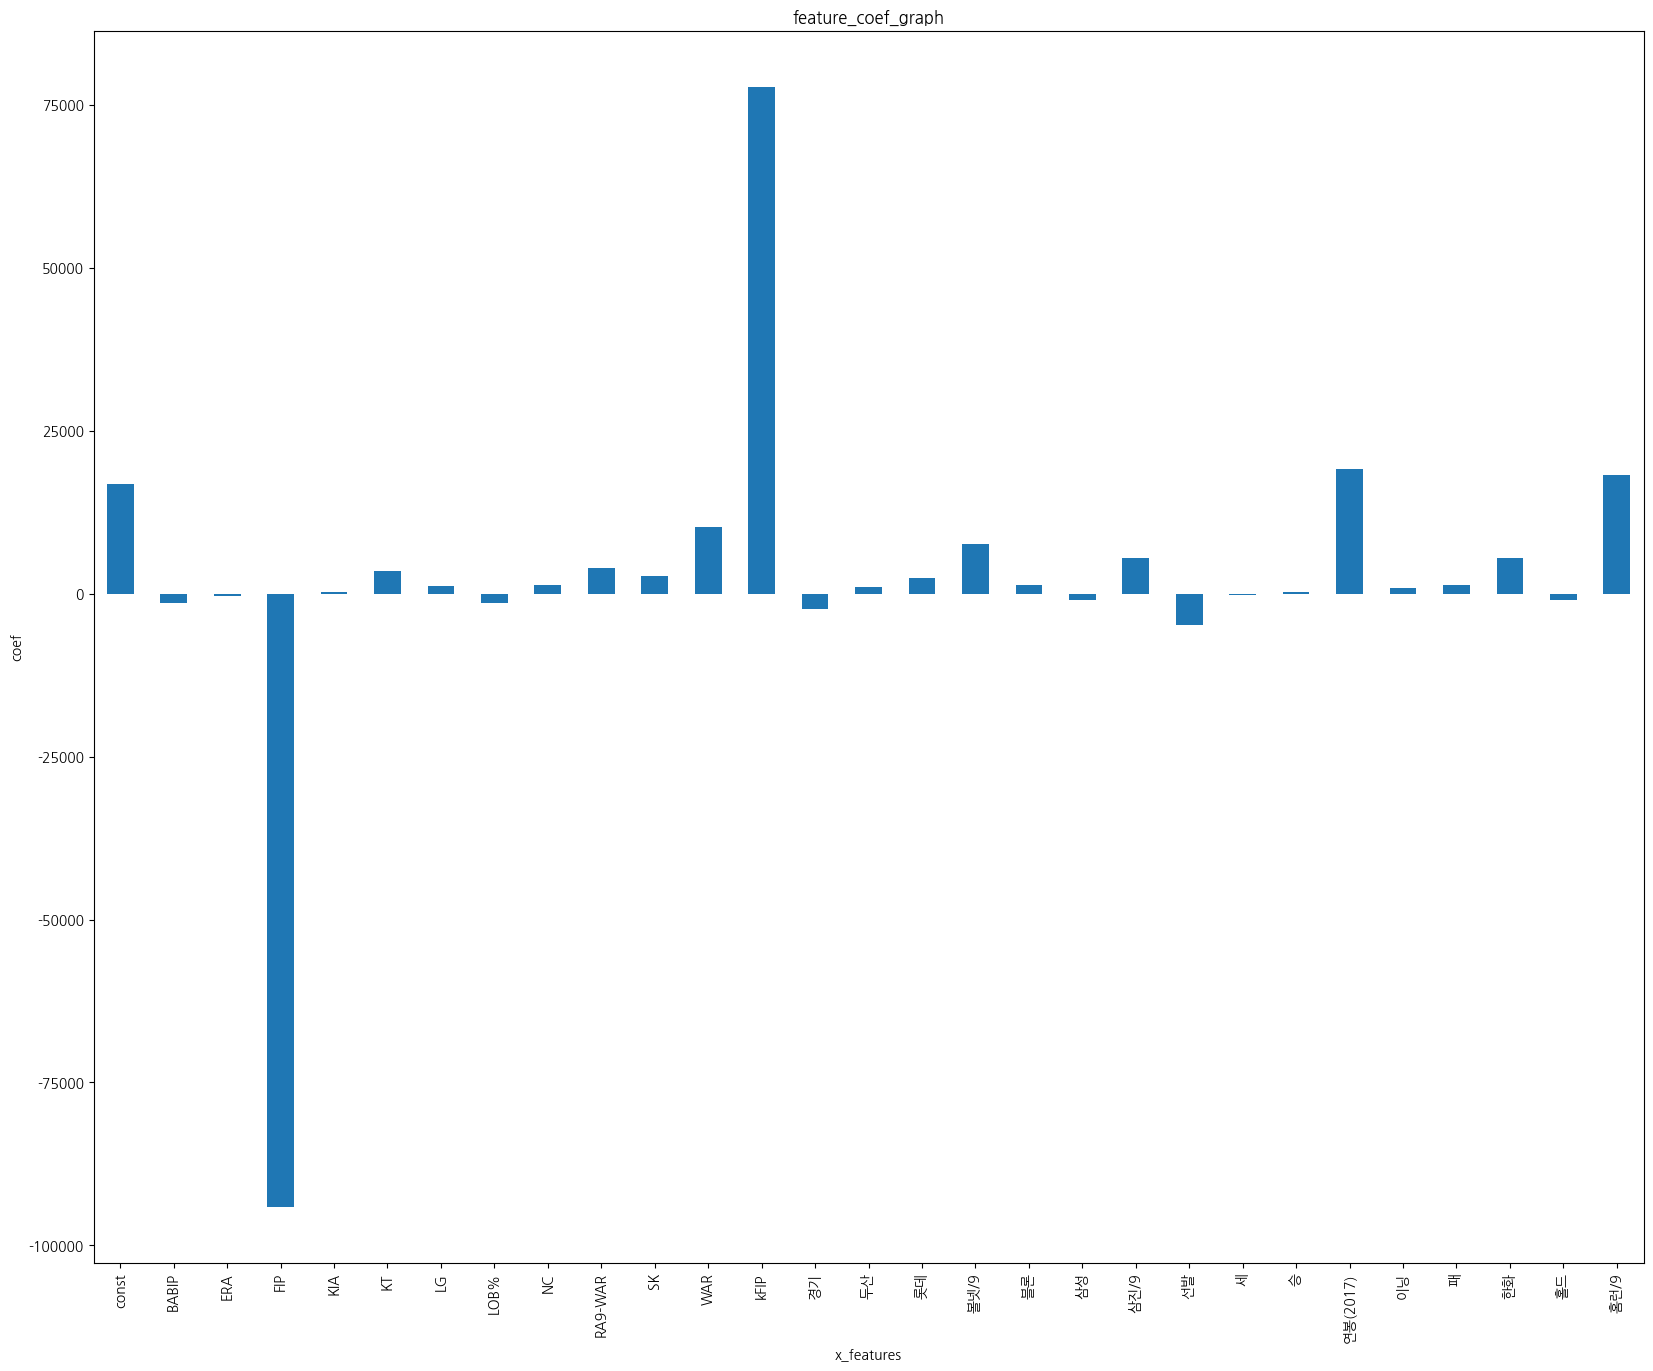

In [36]:
#회귀 계수를 그래프로 나타내어 직관적으로 영향력을 확인해보자

# 한글 출력을 위한 사전 설정 단계
mpl.rc('font', family='NanumGothic')
plt.rcParams['figure.figsize'] = [20, 16]

# 회귀 계수를 리스트로 반환
coefs = model.params.tolist()
coefs_series = pd.Series(coefs)

# 변수명을 리스트로 반환
x_labels = model.params.index.tolist()

# 회귀 계수를 출력
ax = coefs_series.plot(kind='bar')
ax.set_title('feature_coef_graph')
ax.set_xlabel('x_features')
ax.set_ylabel('coef')
ax.set_xticklabels(x_labels)

#FIP, kFIP, 홈런, 연봉(2017) 등의 피쳐가 영향력이 강함을 확인할 수 있음

### 예측 모델의 평가

In [37]:
# 학습 데이터와 테스트 데이터 분리(아까와 동일)
X = picher_df[picher_df.columns.difference(['선수명', 'y'])]
y = picher_df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19)

In [38]:
# 회귀 분석 모델을 학습
lr = linear_model.LinearRegression()
model = lr.fit(X_train, y_train)

In [40]:
# 평가 기준 1 > R2 score(0~1)
print(model.score(X_train, y_train)) # train 결과의 R2 score
print(model.score(X_test, y_test)) # test 결과의 R2 score

0.9276949405576705
0.8860171644977815


In [42]:
# 평가 기준 2 > RMSE score (회귀분석 직선과 데이터 사이의 거리 총합의 루트)
y_predictions = lr.predict(X_train)
print(sqrt(mean_squared_error(y_train, y_predictions))) # train 결과의 RMSE score
y_predictions = lr.predict(X_test)
print(sqrt(mean_squared_error(y_test, y_predictions))) # test 결과의 RMSE score

#보통 R2 score와 RMSE score를 함께 본다

7282.7186847463745
14310.696436889153


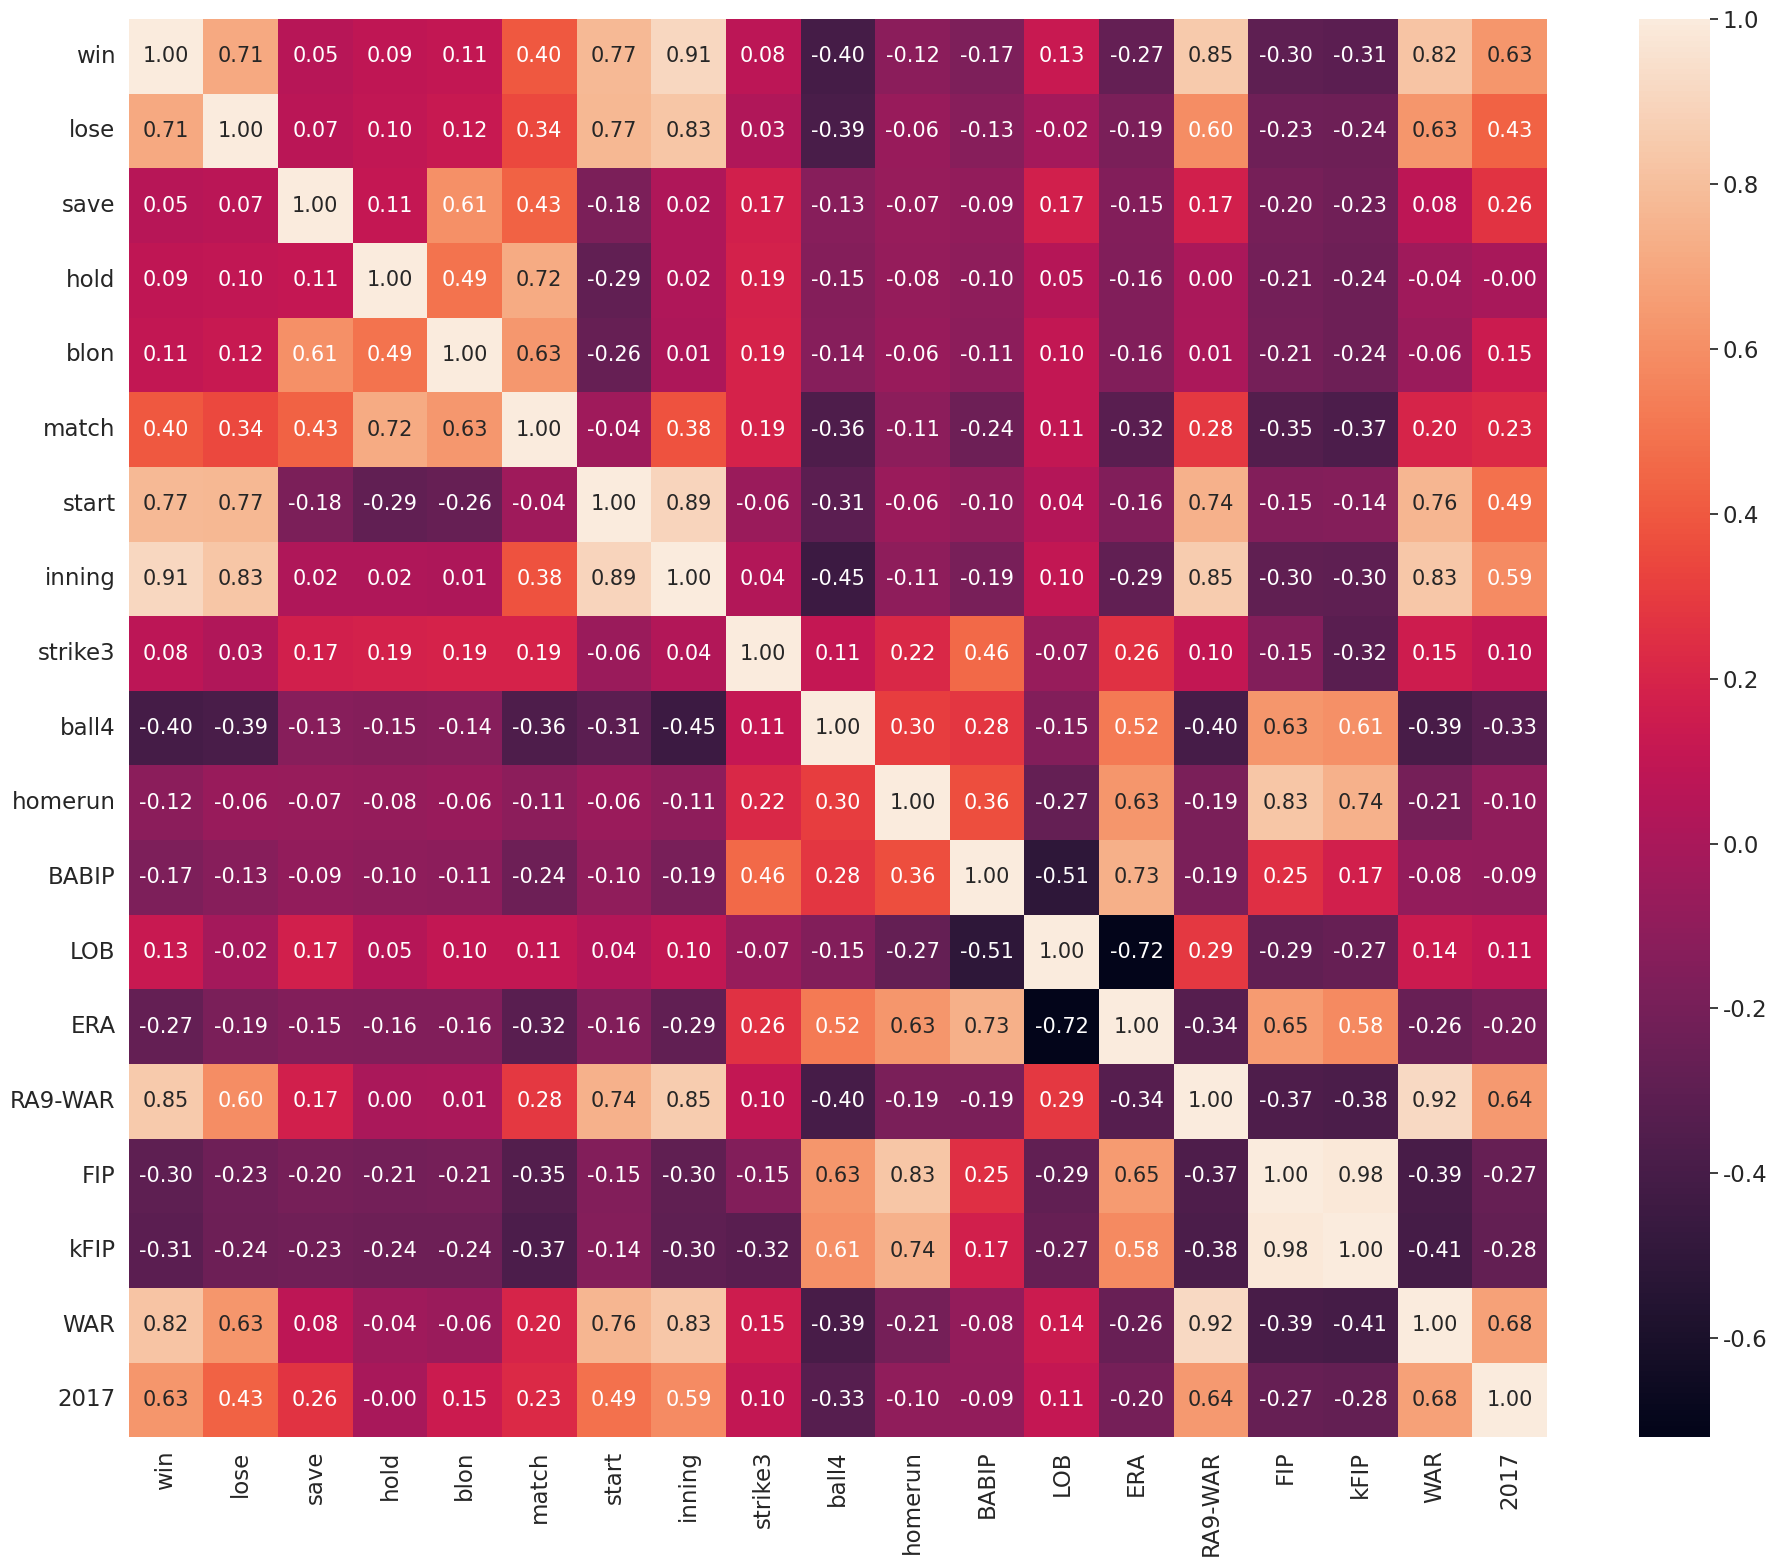

In [44]:
import seaborn as sns

# 피처간의 상관계수 행렬 계산
corr = picher_df[scale_columns].corr(method='pearson')
show_cols = ['win', 'lose', 'save', 'hold', 'blon', 'match', 'start',
             'inning', 'strike3', 'ball4', 'homerun', 'BABIP', 'LOB',
             'ERA', 'RA9-WAR', 'FIP', 'kFIP', 'WAR', '2017']

# 상관계수 행렬(corr) 히트맵을 시각화
plt.rc('font', family='NanumGothicOTF')
sns.set(font_scale=1.5)
hm = sns.heatmap(corr.values,
            cbar=True,
            annot=True,
            square=True,
            fmt='.2f',
            annot_kws={'size': 15},
            yticklabels=show_cols,
            xticklabels=show_cols)

plt.tight_layout()
plt.show()

#대각선 요소들은 자기 자신과의 상관도이므로 1.00
#하지만 서로 다른 피쳐임에도 1.00에 가까운 모습을 보이는 피쳐 관계가 목격됨(kFIP와 FIP)

### 다중공선성을 주의하자.

**다중공선성이란?**

변수간 상관관계가 너무 높아 분석에 부정적인 영향을 미치는 것


각 변수(피쳐)가 어떤 성질을 공유한다거나, 서로간에 영향을 미치는 피쳐일 경우 예측 성능에 영향을 미침

In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [48]:
# 피처마다의 VIF(분산팽창요인) 계수를 출력
# VIF 계산 전에 X 데이터프레임의 타입을 float으로 변환
X = X.astype(float)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

#FIP는 영향력이 크나 공선성이 매우 크므로 유의미한 피쳐라고 볼 수 없다.
#보통 VIF가 10을 초과했을때 공선성이 있다고 본다. 따라서 불필요한 피쳐는 적절히 제거할 필요 있음.
#피쳐를 제거하면 공선성 수치가 달라지므로 확인이 필요!

,VIF Factor,features
0,3.2,BABIP
1,10.6,ERA
2,14238.3,FIP
3,1.1,KIA
4,1.1,KT
5,1.1,LG
6,4.3,LOB%
7,1.1,NC
8,13.6,RA9-WAR
9,1.1,SK


### 적절한 피쳐로 다시 학습하기

In [49]:
# 피처를 재선정
X = picher_df[['FIP', 'WAR', '볼넷/9', '삼진/9', '연봉(2017)']]
y = picher_df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19)

In [50]:
# 모델을 학습 후 결과를 확인해보자!
lr = linear_model.LinearRegression()
model = lr.fit(X_train, y_train)

print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

#이전 테스트 R2스코어에 비해 중가
#train: 0.9276949405576705
#test: 0.8860171644977815

0.9150591192570362
0.9038759653889862


In [51]:
# 피쳐를 줄였을 때의 VIF 계수를 다시 확인해보자
X = picher_df[['FIP', 'WAR', '볼넷/9', '삼진/9', '연봉(2017)']]
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

#몇만까지 치솟던 VIF 수치가 매우 작아졌다! 모델의 공선성과 복잡성 모두 감소하였다.

,VIF Factor,features
0,1.9,FIP
1,2.1,WAR
2,1.9,볼넷/9
3,1.1,삼진/9
4,1.9,연봉(2017)


# 분석 결과 시각화

### 2018년의 예측 연봉과 실제 연봉 비교

In [52]:
# 회귀분석으로 예측한 2018년 연봉을 데이터프레임의 column으로 생성
X = picher_df[['FIP', 'WAR', '볼넷/9', '삼진/9', '연봉(2017)']]
predict_2018_salary = lr.predict(X)
picher_df['예측연봉(2018)'] = pd.Series(predict_2018_salary)

In [53]:
# 원래 데이터 프레임을 다시 로드
picher = pd.read_csv(picher_file_path)
picher = picher[['선수명', '연봉(2017)']]

# 원래의 데이터 프레임에 예측한 2018년 연봉 정보를 합치기
result_df = picher_df.sort_values(by=['y'], ascending=False)
result_df.drop(['연봉(2017)'], axis=1, inplace=True, errors='ignore')
result_df = result_df.merge(picher, on=['선수명'], how='left')
result_df = result_df[['선수명', 'y', '예측연봉(2018)', '연봉(2017)']]
result_df.columns = ['선수명', '실제연봉(2018)', '예측연봉(2018)', '작년연봉(2017)']

# 재계약해 연봉이 변화한 선수만을 대상으로 시각화
result_df = result_df[result_df['작년연봉(2017)'] != result_df['실제연봉(2018)']]
result_df = result_df.reset_index()
result_df = result_df.iloc[:10, :]
result_df.head(10)

,index,선수명,실제연봉(2018),예측연봉(2018),작년연봉(2017)
0,0,양현종,230000,163930.148696,150000
1,1,켈리,140000,120122.822204,85000
2,2,소사,120000,88127.019455,50000
3,4,레일리,111000,102253.697589,85000
4,7,피어밴드,85000,58975.725734,35000
5,15,배영수,50000,56873.662417,55000
6,21,안영명,35000,22420.790838,20000
7,22,채병용,30000,21178.955105,25000
8,23,류제국,29000,45122.360087,35000
9,24,박정진,25000,29060.748299,33000


<Axes: xlabel='선수명'>

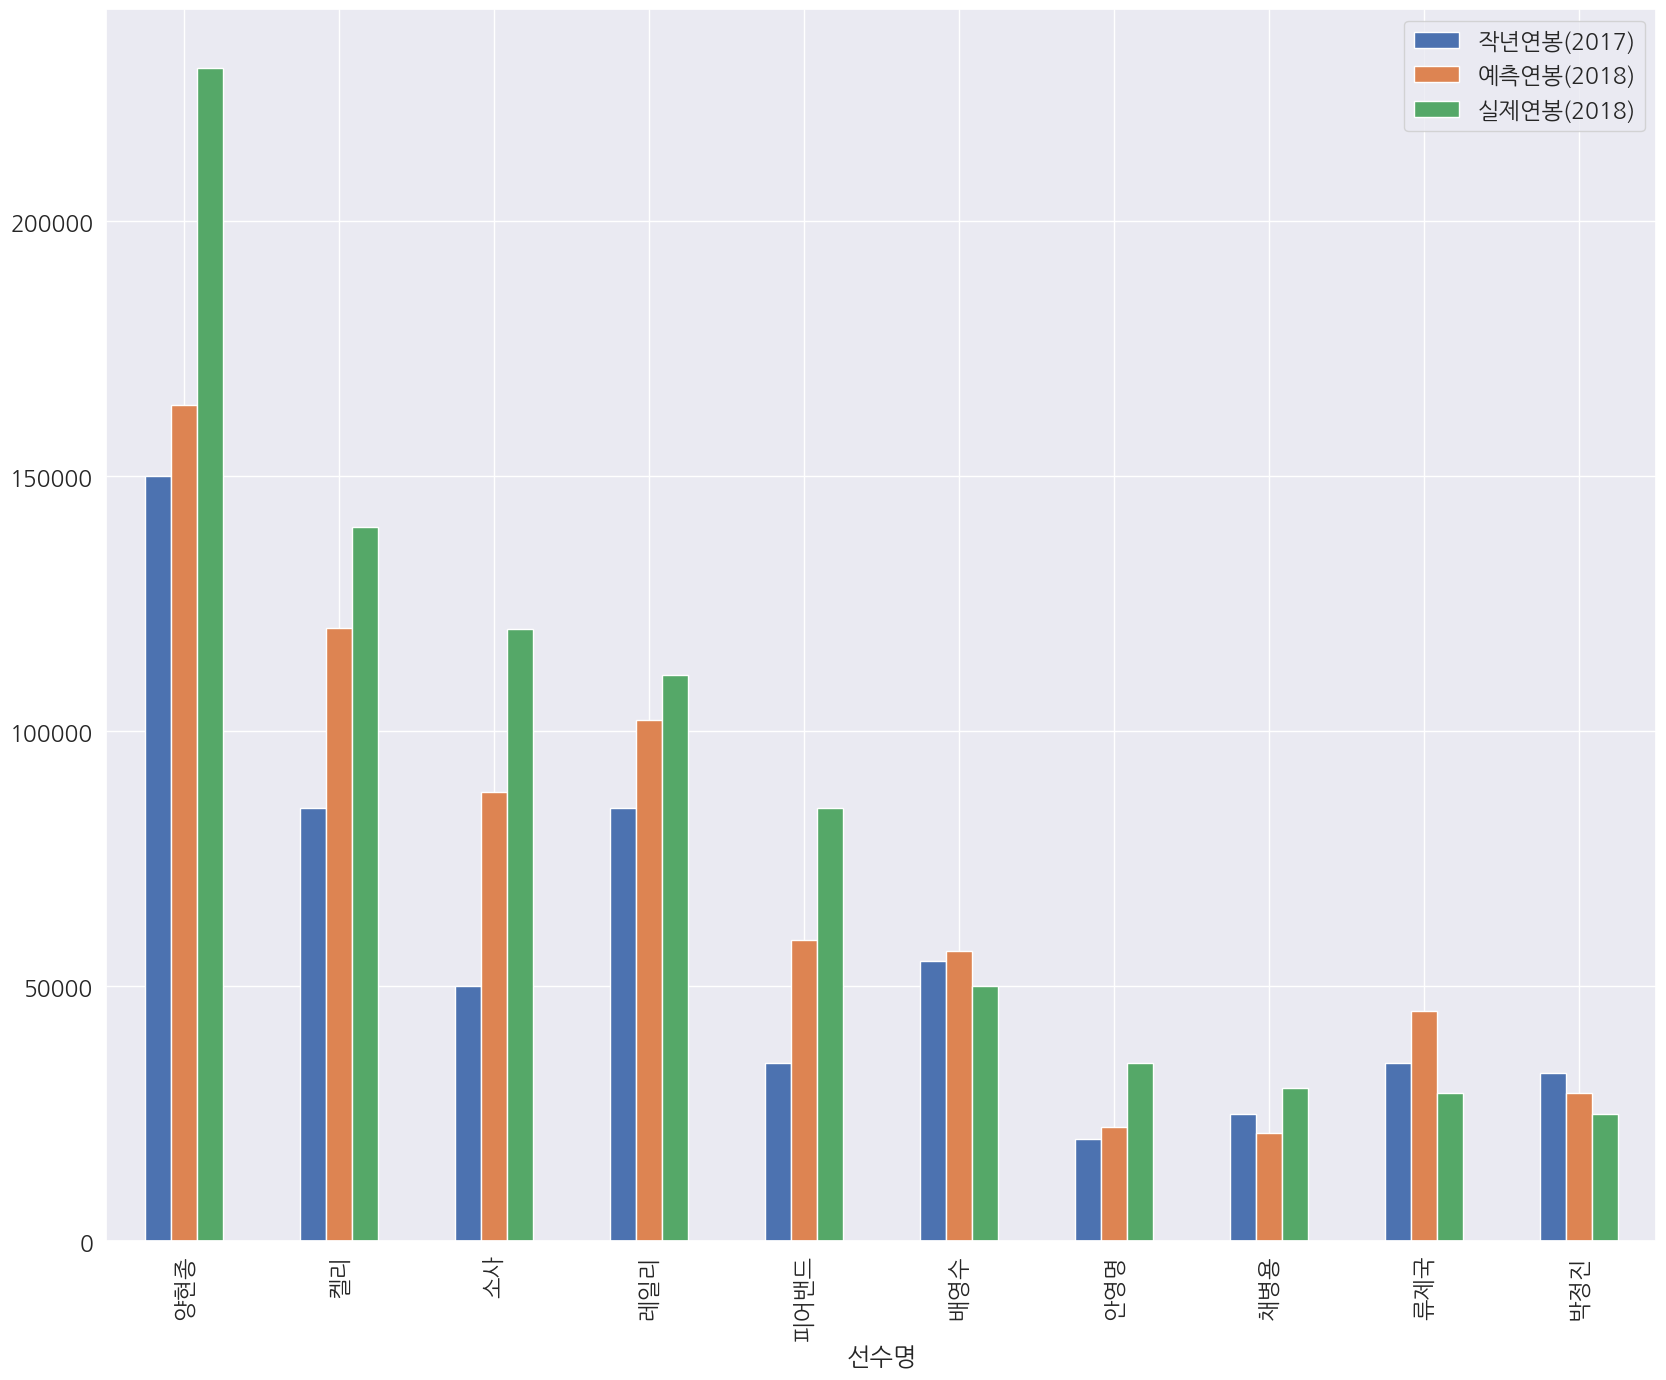

In [54]:
# 직관적인 확인을 위해 선수별 연봉 정보를 bar 그래프로도 출력
mpl.rc('font', family='NanumGothic')
result_df.plot(x='선수명', y=['작년연봉(2017)', '예측연봉(2018)', '실제연봉(2018)'], kind="bar")

#확인 결과, 대부분의 선수가 예측 연봉보다 실제 연봉을 더 높게 받음
#배영수, 안영명, 채병용, 류재국 선수의 경우 예측 방향과 반대로 연봉을 받았음을 확인 가능하다.